In [1]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F

from typing import Any, Callable, List, Optional, Sequence, Tuple, Union
import math
from functools import partial

### Torchvision helpers

In [2]:
class MLP(torch.nn.Sequential):
    """This block implements the multi-layer perceptron (MLP) module.

    Args:
        in_channels (int): Number of channels of the input
        hidden_channels (List[int]): List of the hidden channel dimensions
        norm_layer (Callable[..., torch.nn.Module], optional): Norm layer that will be stacked on top of the linear layer. If ``None`` this layer won't be used. Default: ``None``
        activation_layer (Callable[..., torch.nn.Module], optional): Activation function which will be stacked on top of the normalization layer (if not None), otherwise on top of the linear layer. If ``None`` this layer won't be used. Default: ``torch.nn.ReLU``
        inplace (bool, optional): Parameter for the activation layer, which can optionally do the operation in-place.
            Default is ``None``, which uses the respective default values of the ``activation_layer`` and Dropout layer.
        bias (bool): Whether to use bias in the linear layer. Default ``True``
        dropout (float): The probability for the dropout layer. Default: 0.0
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: List[int],
        norm_layer: Optional[Callable[..., torch.nn.Module]] = None,
        activation_layer: Optional[Callable[..., torch.nn.Module]] = torch.nn.ReLU,
        inplace: Optional[bool] = None,
        bias: bool = True,
        dropout: float = 0.0,
    ):
        params = {} if inplace is None else {"inplace": inplace}

        layers = []
        in_dim = in_channels
        for hidden_dim in hidden_channels[:-1]:
            layers.append(torch.nn.Linear(in_dim, hidden_dim, bias=bias))
            if norm_layer is not None:
                layers.append(norm_layer(hidden_dim))
            layers.append(activation_layer(**params))
            layers.append(torch.nn.Dropout(dropout, **params))
            in_dim = hidden_dim

        layers.append(torch.nn.Linear(in_dim, hidden_channels[-1], bias=bias))
        layers.append(torch.nn.Dropout(dropout, **params))

        super().__init__(*layers)


class Permute(torch.nn.Module):
    """This module returns a view of the tensor input with its dimensions permuted.

    Args:
        dims (List[int]): The desired ordering of dimensions
    """

    def __init__(self, dims: List[int]):
        super().__init__()
        self.dims = dims

    def forward(self, x: Tensor) -> Tensor:
        return torch.permute(x, self.dims)


def stochastic_depth(input: Tensor, p: float, mode: str, training: bool = True) -> Tensor:
    """
    Implements the Stochastic Depth from `"Deep Networks with Stochastic Depth"
    <https://arxiv.org/abs/1603.09382>`_ used for randomly dropping residual
    branches of residual architectures.

    Args:
        input (Tensor[N, ...]): The input tensor or arbitrary dimensions with the first one
                    being its batch i.e. a batch with ``N`` rows.
        p (float): probability of the input to be zeroed.
        mode (str): ``"batch"`` or ``"row"``.
                    ``"batch"`` randomly zeroes the entire input, ``"row"`` zeroes
                    randomly selected rows from the batch.
        training: apply stochastic depth if is ``True``. Default: ``True``

    Returns:
        Tensor[N, ...]: The randomly zeroed tensor.
    """
    if p < 0.0 or p > 1.0:
        raise ValueError(f"drop probability has to be between 0 and 1, but got {p}")
    if mode not in ["batch", "row"]:
        raise ValueError(f"mode has to be either 'batch' or 'row', but got {mode}")
    if not training or p == 0.0:
        return input

    survival_rate = 1.0 - p
    if mode == "row":
        size = [input.shape[0]] + [1] * (input.ndim - 1)
    else:
        size = [1] * input.ndim
    noise = torch.empty(size, dtype=input.dtype, device=input.device)
    noise = noise.bernoulli_(survival_rate)
    if survival_rate > 0.0:
        noise.div_(survival_rate)
    return input * noise


class StochasticDepth(nn.Module):
    """
    See :func:`stochastic_depth`.
    """

    def __init__(self, p: float, mode: str) -> None:
        super().__init__()
        self.p = p
        self.mode = mode

    def forward(self, input: Tensor) -> Tensor:
        return stochastic_depth(input, self.p, self.mode, self.training)

    def __repr__(self) -> str:
        s = f"{self.__class__.__name__}(p={self.p}, mode={self.mode})"
        return s

### Torchvision Swin Arch(s)

In [3]:
def _patch_merging_pad(x: torch.Tensor) -> torch.Tensor:
    H, W, _ = x.shape[-3:]
    x = F.pad(x, (0, 0, 0, W % 2, 0, H % 2))
    x0 = x[..., 0::2, 0::2, :]  # ... H/2 W/2 C
    x1 = x[..., 1::2, 0::2, :]  # ... H/2 W/2 C
    x2 = x[..., 0::2, 1::2, :]  # ... H/2 W/2 C
    x3 = x[..., 1::2, 1::2, :]  # ... H/2 W/2 C
    x = torch.cat([x0, x1, x2, x3], -1)  # ... H/2 W/2 4*C
    return x


def _get_relative_position_bias(
    relative_position_bias_table: torch.Tensor, relative_position_index: torch.Tensor, window_size: List[int]
) -> torch.Tensor:
    N = window_size[0] * window_size[1]
    relative_position_bias = relative_position_bias_table[relative_position_index]  # type: ignore[index]
    relative_position_bias = relative_position_bias.view(N, N, -1)
    relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous().unsqueeze(0)
    return relative_position_bias


In [4]:
class PatchMerging(nn.Module):
    """Patch Merging Layer.
    Args:
        dim (int): Number of input channels.
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
    """

    def __init__(self, dim: int, norm_layer: Callable[..., nn.Module] = nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x: Tensor):
        """
        Args:
            x (Tensor): input tensor with expected layout of [..., H, W, C]
        Returns:
            Tensor with layout of [..., H/2, W/2, 2*C]
        """
        x = _patch_merging_pad(x)
        x = self.norm(x)
        x = self.reduction(x)  # ... H/2 W/2 2*C
        return x


class PatchMergingV2(nn.Module):
    """Patch Merging Layer for Swin Transformer V2.
    Args:
        dim (int): Number of input channels.
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
    """

    def __init__(self, dim: int, norm_layer: Callable[..., nn.Module] = nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(2 * dim)  # difference

    def forward(self, x: Tensor):
        """
        Args:
            x (Tensor): input tensor with expected layout of [..., H, W, C]
        Returns:
            Tensor with layout of [..., H/2, W/2, 2*C]
        """
        x = _patch_merging_pad(x)
        x = self.reduction(x)  # ... H/2 W/2 2*C
        x = self.norm(x)
        return x

In [5]:
def shifted_window_attention(
    input: Tensor,
    qkv_weight: Tensor,
    proj_weight: Tensor,
    relative_position_bias: Tensor,
    window_size: List[int],
    num_heads: int,
    shift_size: List[int],
    attention_dropout: float = 0.0,
    dropout: float = 0.0,
    qkv_bias: Optional[Tensor] = None,
    proj_bias: Optional[Tensor] = None,
    logit_scale: Optional[torch.Tensor] = None,
    training: bool = True,
) -> Tensor:
    """
    Window based multi-head self attention (W-MSA) module with relative position bias.
    It supports both of shifted and non-shifted window.
    Args:
        input (Tensor[N, H, W, C]): The input tensor or 4-dimensions.
        qkv_weight (Tensor[in_dim, out_dim]): The weight tensor of query, key, value.
        proj_weight (Tensor[out_dim, out_dim]): The weight tensor of projection.
        relative_position_bias (Tensor): The learned relative position bias added to attention.
        window_size (List[int]): Window size.
        num_heads (int): Number of attention heads.
        shift_size (List[int]): Shift size for shifted window attention.
        attention_dropout (float): Dropout ratio of attention weight. Default: 0.0.
        dropout (float): Dropout ratio of output. Default: 0.0.
        qkv_bias (Tensor[out_dim], optional): The bias tensor of query, key, value. Default: None.
        proj_bias (Tensor[out_dim], optional): The bias tensor of projection. Default: None.
        logit_scale (Tensor[out_dim], optional): Logit scale of cosine attention for Swin Transformer V2. Default: None.
        training (bool, optional): Training flag used by the dropout parameters. Default: True.
    Returns:
        Tensor[N, H, W, C]: The output tensor after shifted window attention.
    """
    B, H, W, C = input.shape
    # pad feature maps to multiples of window size
    pad_r = (window_size[1] - W % window_size[1]) % window_size[1]
    pad_b = (window_size[0] - H % window_size[0]) % window_size[0]
    x = F.pad(input, (0, 0, 0, pad_r, 0, pad_b))
    _, pad_H, pad_W, _ = x.shape

    shift_size = shift_size.copy()
    # If window size is larger than feature size, there is no need to shift window
    if window_size[0] >= pad_H:
        shift_size[0] = 0
    if window_size[1] >= pad_W:
        shift_size[1] = 0

    # cyclic shift
    if sum(shift_size) > 0:
        x = torch.roll(x, shifts=(-shift_size[0], -shift_size[1]), dims=(1, 2))

    # partition windows
    num_windows = (pad_H // window_size[0]) * (pad_W // window_size[1])
    x = x.view(B, pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1], C)
    x = x.permute(0, 1, 3, 2, 4, 5).reshape(B * num_windows, window_size[0] * window_size[1], C)  # B*nW, Ws*Ws, C

    # multi-head attention
    if logit_scale is not None and qkv_bias is not None:
        qkv_bias = qkv_bias.clone()
        length = qkv_bias.numel() // 3
        qkv_bias[length : 2 * length].zero_()
    qkv = F.linear(x, qkv_weight, qkv_bias)
    qkv = qkv.reshape(x.size(0), x.size(1), 3, num_heads, C // num_heads).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]
    if logit_scale is not None:
        # cosine attention
        attn = F.normalize(q, dim=-1) @ F.normalize(k, dim=-1).transpose(-2, -1)
        logit_scale = torch.clamp(logit_scale, max=math.log(100.0)).exp()
        attn = attn * logit_scale
    else:
        q = q * (C // num_heads) ** -0.5
        attn = q.matmul(k.transpose(-2, -1))
    # add relative position bias
    attn = attn + relative_position_bias

    if sum(shift_size) > 0:
        # generate attention mask
        attn_mask = x.new_zeros((pad_H, pad_W))
        h_slices = ((0, -window_size[0]), (-window_size[0], -shift_size[0]), (-shift_size[0], None))
        w_slices = ((0, -window_size[1]), (-window_size[1], -shift_size[1]), (-shift_size[1], None))
        count = 0
        for h in h_slices:
            for w in w_slices:
                attn_mask[h[0] : h[1], w[0] : w[1]] = count
                count += 1
        attn_mask = attn_mask.view(pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1])
        attn_mask = attn_mask.permute(0, 2, 1, 3).reshape(num_windows, window_size[0] * window_size[1])
        attn_mask = attn_mask.unsqueeze(1) - attn_mask.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        attn = attn.view(x.size(0) // num_windows, num_windows, num_heads, x.size(1), x.size(1))
        attn = attn + attn_mask.unsqueeze(1).unsqueeze(0)
        attn = attn.view(-1, num_heads, x.size(1), x.size(1))

    attn = F.softmax(attn, dim=-1)
    attn = F.dropout(attn, p=attention_dropout, training=training)

    x = attn.matmul(v).transpose(1, 2).reshape(x.size(0), x.size(1), C)
    x = F.linear(x, proj_weight, proj_bias)
    x = F.dropout(x, p=dropout, training=training)

    # reverse windows
    x = x.view(B, pad_H // window_size[0], pad_W // window_size[1], window_size[0], window_size[1], C)
    x = x.permute(0, 1, 3, 2, 4, 5).reshape(B, pad_H, pad_W, C)

    # reverse cyclic shift
    if sum(shift_size) > 0:
        x = torch.roll(x, shifts=(shift_size[0], shift_size[1]), dims=(1, 2))

    # unpad features
    x = x[:, :H, :W, :].contiguous()
    return x


class ShiftedWindowAttention(nn.Module):
    """
    See :func:`shifted_window_attention`.
    """

    def __init__(
        self,
        dim: int,
        window_size: List[int],
        shift_size: List[int],
        num_heads: int,
        qkv_bias: bool = True,
        proj_bias: bool = True,
        attention_dropout: float = 0.0,
        dropout: float = 0.0,
    ):
        super().__init__()
        if len(window_size) != 2 or len(shift_size) != 2:
            raise ValueError("window_size and shift_size must be of length 2")
        self.window_size = window_size
        self.shift_size = shift_size
        self.num_heads = num_heads
        self.attention_dropout = attention_dropout
        self.dropout = dropout

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim, bias=proj_bias)

        self.define_relative_position_bias_table()
        self.define_relative_position_index()

    def define_relative_position_bias_table(self):
        # define a parameter table of relative position bias
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1), self.num_heads)
        )  # 2*Wh-1 * 2*Ww-1, nH
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

    def define_relative_position_index(self):
        # get pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, Wh*Ww, Wh*Ww
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # Wh*Ww, Wh*Ww, 2
        relative_coords[:, :, 0] += self.window_size[0] - 1  # shift to start from 0
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1).flatten()  # Wh*Ww*Wh*Ww
        self.register_buffer("relative_position_index", relative_position_index)

    def get_relative_position_bias(self) -> torch.Tensor:
        return _get_relative_position_bias(
            self.relative_position_bias_table, self.relative_position_index, self.window_size  # type: ignore[arg-type]
        )

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x (Tensor): Tensor with layout of [B, H, W, C]
        Returns:
            Tensor with same layout as input, i.e. [B, H, W, C]
        """
        relative_position_bias = self.get_relative_position_bias()
        return shifted_window_attention(
            x,
            self.qkv.weight,
            self.proj.weight,
            relative_position_bias,
            self.window_size,
            self.num_heads,
            shift_size=self.shift_size,
            attention_dropout=self.attention_dropout,
            dropout=self.dropout,
            qkv_bias=self.qkv.bias,
            proj_bias=self.proj.bias,
            training=self.training,
        )


class ShiftedWindowAttentionV2(ShiftedWindowAttention):
    """
    See :func:`shifted_window_attention_v2`.
    """

    def __init__(
        self,
        dim: int,
        window_size: List[int],
        shift_size: List[int],
        num_heads: int,
        qkv_bias: bool = True,
        proj_bias: bool = True,
        attention_dropout: float = 0.0,
        dropout: float = 0.0,
    ):
        super().__init__(
            dim,
            window_size,
            shift_size,
            num_heads,
            qkv_bias=qkv_bias,
            proj_bias=proj_bias,
            attention_dropout=attention_dropout,
            dropout=dropout,
        )

        self.logit_scale = nn.Parameter(torch.log(10 * torch.ones((num_heads, 1, 1))))
        # mlp to generate continuous relative position bias
        self.cpb_mlp = nn.Sequential(
            nn.Linear(2, 512, bias=True), nn.ReLU(inplace=True), nn.Linear(512, num_heads, bias=False)
        )
        if qkv_bias:
            length = self.qkv.bias.numel() // 3
            self.qkv.bias[length : 2 * length].data.zero_()

    def define_relative_position_bias_table(self):
        # get relative_coords_table
        relative_coords_h = torch.arange(-(self.window_size[0] - 1), self.window_size[0], dtype=torch.float32)
        relative_coords_w = torch.arange(-(self.window_size[1] - 1), self.window_size[1], dtype=torch.float32)
        relative_coords_table = torch.stack(torch.meshgrid([relative_coords_h, relative_coords_w], indexing="ij"))
        relative_coords_table = relative_coords_table.permute(1, 2, 0).contiguous().unsqueeze(0)  # 1, 2*Wh-1, 2*Ww-1, 2

        relative_coords_table[:, :, :, 0] /= self.window_size[0] - 1
        relative_coords_table[:, :, :, 1] /= self.window_size[1] - 1

        relative_coords_table *= 8  # normalize to -8, 8
        relative_coords_table = (
            torch.sign(relative_coords_table) * torch.log2(torch.abs(relative_coords_table) + 1.0) / 3.0
        )
        self.register_buffer("relative_coords_table", relative_coords_table)

    def get_relative_position_bias(self) -> torch.Tensor:
        relative_position_bias = _get_relative_position_bias(
            self.cpb_mlp(self.relative_coords_table).view(-1, self.num_heads),
            self.relative_position_index,  # type: ignore[arg-type]
            self.window_size,
        )
        relative_position_bias = 16 * torch.sigmoid(relative_position_bias)
        return relative_position_bias

    def forward(self, x: Tensor):
        """
        Args:
            x (Tensor): Tensor with layout of [B, H, W, C]
        Returns:
            Tensor with same layout as input, i.e. [B, H, W, C]
        """
        relative_position_bias = self.get_relative_position_bias()
        return shifted_window_attention(
            x,
            self.qkv.weight,
            self.proj.weight,
            relative_position_bias,
            self.window_size,
            self.num_heads,
            shift_size=self.shift_size,
            attention_dropout=self.attention_dropout,
            dropout=self.dropout,
            qkv_bias=self.qkv.bias,
            proj_bias=self.proj.bias,
            logit_scale=self.logit_scale,
            training=self.training,
        )

In [6]:

class SwinTransformerBlock(nn.Module):
    """
    Swin Transformer Block.
    Args:
        dim (int): Number of input channels.
        num_heads (int): Number of attention heads.
        window_size (List[int]): Window size.
        shift_size (List[int]): Shift size for shifted window attention.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.0.
        dropout (float): Dropout rate. Default: 0.0.
        attention_dropout (float): Attention dropout rate. Default: 0.0.
        stochastic_depth_prob: (float): Stochastic depth rate. Default: 0.0.
        norm_layer (nn.Module): Normalization layer.  Default: nn.LayerNorm.
        attn_layer (nn.Module): Attention layer. Default: ShiftedWindowAttention
    """

    def __init__(
        self,
        dim: int,
        num_heads: int,
        window_size: List[int],
        shift_size: List[int],
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        stochastic_depth_prob: float = 0.0,
        norm_layer: Callable[..., nn.Module] = nn.LayerNorm,
        attn_layer: Callable[..., nn.Module] = ShiftedWindowAttention,
    ):
        super().__init__()

        self.norm1 = norm_layer(dim)
        self.attn = attn_layer(
            dim,
            window_size,
            shift_size,
            num_heads,
            attention_dropout=attention_dropout,
            dropout=dropout,
        )
        self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")
        self.norm2 = norm_layer(dim)
        self.mlp = MLP(dim, [int(dim * mlp_ratio), dim], activation_layer=nn.GELU, inplace=None, dropout=dropout)

        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.normal_(m.bias, std=1e-6)

    def forward(self, x: Tensor):
        x = x + self.stochastic_depth(self.attn(self.norm1(x)))
        x = x + self.stochastic_depth(self.mlp(self.norm2(x)))
        return x


class SwinTransformerBlockV2(SwinTransformerBlock):
    """
    Swin Transformer V2 Block.
    Args:
        dim (int): Number of input channels.
        num_heads (int): Number of attention heads.
        window_size (List[int]): Window size.
        shift_size (List[int]): Shift size for shifted window attention.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.0.
        dropout (float): Dropout rate. Default: 0.0.
        attention_dropout (float): Attention dropout rate. Default: 0.0.
        stochastic_depth_prob: (float): Stochastic depth rate. Default: 0.0.
        norm_layer (nn.Module): Normalization layer.  Default: nn.LayerNorm.
        attn_layer (nn.Module): Attention layer. Default: ShiftedWindowAttentionV2.
    """

    def __init__(
        self,
        dim: int,
        num_heads: int,
        window_size: List[int],
        shift_size: List[int],
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        stochastic_depth_prob: float = 0.0,
        norm_layer: Callable[..., nn.Module] = nn.LayerNorm,
        attn_layer: Callable[..., nn.Module] = ShiftedWindowAttentionV2,
    ):
        super().__init__(
            dim,
            num_heads,
            window_size,
            shift_size,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            attention_dropout=attention_dropout,
            stochastic_depth_prob=stochastic_depth_prob,
            norm_layer=norm_layer,
            attn_layer=attn_layer,
        )

    def forward(self, x: Tensor):
        # Here is the difference, we apply norm after the attention in V2.
        # In V1 we applied norm before the attention.
        x = x + self.stochastic_depth(self.norm1(self.attn(x)))
        x = x + self.stochastic_depth(self.norm2(self.mlp(x)))
        return x


class SwinTransformer(nn.Module):
    """
    Implements Swin Transformer from the `"Swin Transformer: Hierarchical Vision Transformer using
    Shifted Windows" <https://arxiv.org/abs/2103.14030>`_ paper.
    Args:
        patch_size (List[int]): Patch size.
        embed_dim (int): Patch embedding dimension.
        depths (List(int)): Depth of each Swin Transformer layer.
        num_heads (List(int)): Number of attention heads in different layers.
        window_size (List[int]): Window size.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.0.
        dropout (float): Dropout rate. Default: 0.0.
        attention_dropout (float): Attention dropout rate. Default: 0.0.
        stochastic_depth_prob (float): Stochastic depth rate. Default: 0.1.
        num_classes (int): Number of classes for classification head. Default: 1000.
        block (nn.Module, optional): SwinTransformer Block. Default: None.
        norm_layer (nn.Module, optional): Normalization layer. Default: None.
        downsample_layer (nn.Module): Downsample layer (patch merging). Default: PatchMerging.
    """

    def __init__(
        self,
        patch_size: List[int],
        embed_dim: int,
        depths: List[int],
        num_heads: List[int],
        window_size: List[int],
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        stochastic_depth_prob: float = 0.1,
        num_classes: int = 1000,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
        block: Optional[Callable[..., nn.Module]] = None,
        downsample_layer: Callable[..., nn.Module] = PatchMerging,
    ):
        super().__init__()
        self.num_classes = num_classes

        if block is None:
            block = SwinTransformerBlock
        if norm_layer is None:
            norm_layer = partial(nn.LayerNorm, eps=1e-5)

        layers: List[nn.Module] = []
        # split image into non-overlapping patches
        layers.append(
            nn.Sequential(
                nn.Conv2d(
                    3, embed_dim, kernel_size=(patch_size[0], patch_size[1]), stride=(patch_size[0], patch_size[1])
                ),
                Permute([0, 2, 3, 1]),
                norm_layer(embed_dim),
            )
        )

        total_stage_blocks = sum(depths)
        stage_block_id = 0
        # build SwinTransformer blocks
        for i_stage in range(len(depths)):
            stage: List[nn.Module] = []
            dim = embed_dim * 2**i_stage
            for i_layer in range(depths[i_stage]):
                # adjust stochastic depth probability based on the depth of the stage block
                sd_prob = stochastic_depth_prob * float(stage_block_id) / (total_stage_blocks - 1)
                stage.append(
                    block(
                        dim,
                        num_heads[i_stage],
                        window_size=window_size,
                        shift_size=[0 if i_layer % 2 == 0 else w // 2 for w in window_size],
                        mlp_ratio=mlp_ratio,
                        dropout=dropout,
                        attention_dropout=attention_dropout,
                        stochastic_depth_prob=sd_prob,
                        norm_layer=norm_layer,
                    )
                )
                stage_block_id += 1
            layers.append(nn.Sequential(*stage))
            # add patch merging layer
            if i_stage < (len(depths) - 1):
                layers.append(downsample_layer(dim, norm_layer))
        self.features = nn.Sequential(*layers)

        num_features = embed_dim * 2 ** (len(depths) - 1)
        self.norm = norm_layer(num_features)
        self.permute = Permute([0, 3, 1, 2])  # B H W C -> B C H W
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten(1)
        self.head = nn.Linear(num_features, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.norm(x)
        x = self.permute(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.head(x)
        return x

In [7]:
# # Swin T
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=96,
#     depths=[2, 2, 6, 2],
#     num_heads=[3, 6, 12, 24],
#     window_size=[7, 7],
#     stochastic_depth_prob=0.2,
#     **kwargs,
# )


# # Swin S
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=96,
#     depths=[2, 2, 18, 2],
#     num_heads=[3, 6, 12, 24],
#     window_size=[7, 7],
#     stochastic_depth_prob=0.3,
#     **kwargs,
# )


# #Swin B
# SwinTransformer(
#         patch_size=[4, 4],
#         embed_dim=128,
#         depths=[2, 2, 18, 2],
#         num_heads=[4, 8, 16, 32],
#         window_size=[7, 7],
#         stochastic_depth_prob=0.5,
#         **kwargs,
#     )


# # Swin V2 T
# SwinTransformer(
#         patch_size=[4, 4],
#         embed_dim=96,
#         depths=[2, 2, 6, 2],
#         num_heads=[3, 6, 12, 24],
#         window_size=[8, 8],
#         stochastic_depth_prob=0.2,
#         block=SwinTransformerBlockV2,
#         downsample_layer=PatchMergingV2,
#         **kwargs,
#     )


# # Swin V2 S
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=96,
#     depths=[2, 2, 18, 2],
#     num_heads=[3, 6, 12, 24],
#     window_size=[8, 8],
#     stochastic_depth_prob=0.3,
#     block=SwinTransformerBlockV2,
#     downsample_layer=PatchMergingV2,
#     **kwargs,
# )

# # Swin V2 B
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=128,
#     depths=[2, 2, 18, 2],
#     num_heads=[4, 8, 16, 32],
#     window_size=[8, 8],
#     stochastic_depth_prob=0.5,
#     block=SwinTransformerBlockV2,
#     downsample_layer=PatchMergingV2,
#     **kwargs,
# )

### Relative Position Bias

Shape(Bias Matrix/Table) = (2M-1) x (2M-1)




In [140]:
window_size = torch.tensor([2, 2])
num_heads = 2

In [141]:
def _get_relative_position_bias(
    relative_position_bias_table: torch.Tensor, relative_position_index: torch.Tensor, window_size: List[int]
) -> torch.Tensor:
    N = window_size[0] * window_size[1]
    relative_position_bias = relative_position_bias_table[relative_position_index]  # type: ignore[index]
    relative_position_bias = relative_position_bias.view(N, N, -1)
    relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous().unsqueeze(0)
    return relative_position_bias

#### V1

In [168]:
 def define_relative_position_bias_table():
    # define a parameter table of relative position bias
    relative_position_bias_table = nn.Parameter(
        torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads)
    )  # 2*Wh-1 * 2*Ww-1, nH
    nn.init.trunc_normal_(relative_position_bias_table, std=0.02)
    return relative_position_bias_table

def define_relative_position_index():
    # get pair-wise relative position index for each token inside the window
    coords_h = torch.arange(window_size[0])
    coords_w = torch.arange(window_size[1])
    print("coords_h", coords_h)
    coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))  # 2, Wh, Ww
    print("coords", coords)
    coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
    print("coords", coords_flatten)
    relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, Wh*Ww, Wh*Ww
    print("relative_coords", relative_coords)
    relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # Wh*Ww, Wh*Ww, 2
    print("relative_coords", relative_coords)
    relative_coords[:, :, 0] += window_size[0] - 1  # shift to start from 0
    relative_coords[:, :, 1] += window_size[1] - 1
    print("relative_coords", relative_coords)
    relative_coords[:, :, 0] *= 2 * window_size[1] - 1
    print("relative_coords", relative_coords)
    relative_position_index = relative_coords.sum(-1).flatten()  # Wh*Ww*Wh*Ww
    print(relative_position_index)
    return relative_position_index
    # register_buffer("relative_position_index", relative_position_index)

def get_relative_position_bias(relative_position_bias_table, relative_position_index, window_size) -> torch.Tensor:
    return _get_relative_position_bias(
        relative_position_bias_table, relative_position_index, window_size  # type: ignore[arg-type]
    )

In [169]:
relative_position_bias_table = define_relative_position_bias_table()
relative_position_index = define_relative_position_index()
relative_position_bias = get_relative_position_bias(relative_position_bias_table, relative_position_index, window_size)
relative_position_bias.shape

coords_h tensor([0, 1, 2])
coords tensor([[[0, 0, 0],
         [1, 1, 1],
         [2, 2, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]])
coords tensor([[0, 0, 0, 1, 1, 1, 2, 2, 2],
        [0, 1, 2, 0, 1, 2, 0, 1, 2]])
relative_coords tensor([[[ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0]],

        [[ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0],
         [ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0],
         [ 0, -1, -2,  0, -1, -2,  0,

torch.Size([1, 2, 9, 9])

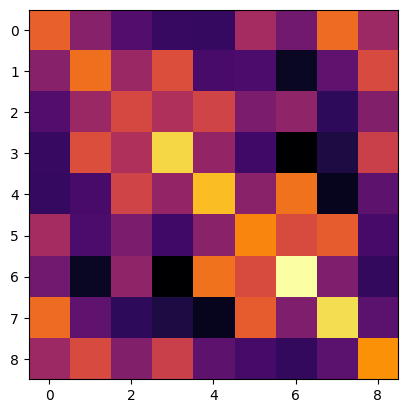

In [162]:
import matplotlib.pyplot as plt
similarity = torch.matmul(relative_position_bias[0,0], relative_position_bias[0,0].T).detach().cpu() #position_embeddings @ position_embeddings.T
plt.imshow(similarity, cmap="inferno")

#### V2

In [154]:
cpb_mlp = nn.Sequential(
            nn.Linear(2, 512, bias=True), nn.ReLU(inplace=True), nn.Linear(512, num_heads, bias=False)
        )

def define_relative_position_bias_table():
    # get relative_coords_table
    relative_coords_h = torch.arange(-(window_size[0] - 1), window_size[0], dtype=torch.float32)
    relative_coords_w = torch.arange(-(window_size[1] - 1), window_size[1], dtype=torch.float32)
    relative_coords_table = torch.stack(torch.meshgrid([relative_coords_h, relative_coords_w], indexing="ij"))
    relative_coords_table = relative_coords_table.permute(1, 2, 0).contiguous().unsqueeze(0)  # 1, 2*Wh-1, 2*Ww-1, 2

    relative_coords_table[:, :, :, 0] /= window_size[0] - 1
    relative_coords_table[:, :, :, 1] /= window_size[1] - 1

    relative_coords_table *= 8  # normalize to -8, 8
    relative_coords_table = (
        torch.sign(relative_coords_table) * torch.log2(torch.abs(relative_coords_table) + 1.0) / 3.0
    )
    return relative_coords_table
    # self.register_buffer("relative_coords_table", relative_coords_table)

def get_relative_position_bias(relative_coords_table, relative_position_index, window_size, num_heads) -> torch.Tensor:
    relative_position_bias = _get_relative_position_bias(
        cpb_mlp(relative_coords_table).view(-1, num_heads),
        relative_position_index,  # type: ignore[arg-type]
        window_size,
    )
    relative_position_bias = 16 * torch.sigmoid(relative_position_bias)
    return relative_position_bias


In [155]:
relative_coords_table = define_relative_position_bias_table()
relative_position_index = define_relative_position_index()
relative_position_bias = get_relative_position_bias(relative_coords_table, relative_position_index, window_size, num_heads)
relative_position_bias.shape

torch.Size([1, 2, 9, 9])

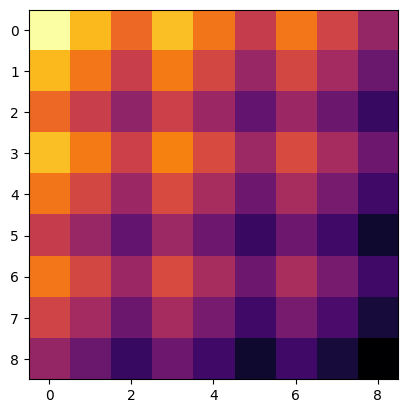

In [156]:
import matplotlib.pyplot as plt
similarity = torch.matmul(relative_position_bias[0,1], relative_position_bias[0,1].T).detach().cpu() #position_embeddings @ position_embeddings.T
plt.imshow(similarity, cmap="inferno")

### Cyclic Shifts

### Full Climate Swin Encoder with Land Masking + Longitude circular padding

### Global Attention (Need to implement)

In [5]:
import torch
import torch.nn as nn

class Conv2DUnequalGroups(nn.Module):
    def __init__(self, in_channels, out_channels_per_group, kernel_size, stride=1, padding=0, bias=True):
        """
        Args:
            in_channels (list): List of input channels for each group.
            out_channels_per_group (list): List of output channels for each group.
            kernel_size (int or tuple): Kernel size for the convolution.
            stride (int or tuple, optional): Stride for the convolution. Default is 1.
            padding (int or tuple, optional): Padding for the convolution. Default is 0.
            bias (bool, optional): Whether to use a bias term. Default is True.
        """
        super().__init__()
        assert len(in_channels) == len(out_channels_per_group), \
            "Mismatch between number of input groups and output groups."
        
        self.groups = nn.ModuleList([
            nn.Conv2d(
                in_channels=in_c,
                out_channels=out_c,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=bias
            )
            for in_c, out_c in zip(in_channels, out_channels_per_group)
        ])
    
    def forward(self, x):
        # Split the input tensor into groups along the channel dimension
        inputs = torch.split(x, [g.in_channels for g in self.groups], dim=1)
        
        # Apply each group's convolution and concatenate the results
        outputs = [group(inp) for group, inp in zip(self.groups, inputs)]
        return torch.cat(outputs, dim=1)

# Example usage
# First
# in_channels = [19, 19, 19, 19, 1]*2 + [4]  # Group 1 has 3 channels, Group 2 has 6 channels
# out_channels_per_group = [19, 19, 19, 19, 1]*2 + [4]  # Group 1 outputs 4 channels, Group 2 outputs 8 channels
# Second
# in_channels = [19, 19, 19, 19, 1] * 2 + [4]  # Group 1 has 3 channels, Group 2 has 6 channels
# out_channels_per_group = [19, 19, 19, 19, 1] * 2 + [4]  # Group 1 outputs 4 channels, Group 2 outputs 8 channels
# print(out_channels_per_group)
kernel_size = 3
stride = 1
padding = 1

# Create the model
conv_unequal = Conv2DUnequalGroups(in_channels, out_channels_per_group, kernel_size, stride, padding)

# Input tensor with batch size 1 and 9 input channels (3 + 6)
input_tensor = torch.randn(1, sum(in_channels), 32, 32)

# Forward pass
output_tensor = conv_unequal(input_tensor)
print(output_tensor.shape)  # Should be [1, sum(out_channels_per_group), 32, 32]

[19, 19, 19, 19, 1, 19, 19, 19, 19, 1, 4]
torch.Size([1, 158, 32, 32])
